In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# 전처리된 데이터 로드
X_train = np.load('../data/processed/X_train.npy')
X_test = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test = np.load('../data/processed/y_test.npy')

print("데이터 로드 완료!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

/var/folders/s9/5g6t7vwn40ngmg0cqw8zz1nh0000gn/T/ipykernel_19282/2940860828.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


데이터 로드 완료!
X_train shape: (82332, 42)
X_test shape: (175341, 42)


In [ ]:
# Isolation Forest 학습
# contamination = 전체 데이터 중 이상치 비율 (공격이 55%니까 0.5로 설정)
print("Isolation Forest 학습 중...")

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.5,
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_train)
print("학습 완료!")

Isolation Forest 학습 중... (1~2분 소요)
학습 완료!


In [3]:
# 예측
# Isolation Forest는 -1(이상) 또는 1(정상)을 반환
# 우리 레이블은 1(공격) 0(정상)이라 변환 필요
y_pred_iso = iso_forest.predict(X_test)
y_pred_iso = np.where(y_pred_iso == -1, 1, 0)  # -1 → 1(공격), 1 → 0(정상)

print("=== Isolation Forest 성능 ===")
print(classification_report(y_test, y_pred_iso))
print("F1 Score:", f1_score(y_test, y_pred_iso).round(3))

=== Isolation Forest 성능 ===
              precision    recall  f1-score   support

           0       0.25      0.38      0.30     56000
           1       0.62      0.48      0.54    119341

    accuracy                           0.45    175341
   macro avg       0.44      0.43      0.42    175341
weighted avg       0.50      0.45      0.47    175341

F1 Score: 0.542


In [4]:
from xgboost import XGBClassifier

print("XGBoost 학습 중...")

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)
print("학습 완료!")

XGBoost 학습 중...
학습 완료!


In [5]:
# XGBoost 예측 및 성능 확인
y_pred_xgb = xgb.predict(X_test)

print("=== XGBoost 성능 ===")
print(classification_report(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb).round(3))

=== XGBoost 성능 ===
              precision    recall  f1-score   support

           0       0.77      0.98      0.86     56000
           1       0.99      0.86      0.92    119341

    accuracy                           0.90    175341
   macro avg       0.88      0.92      0.89    175341
weighted avg       0.92      0.90      0.90    175341

F1 Score: 0.922


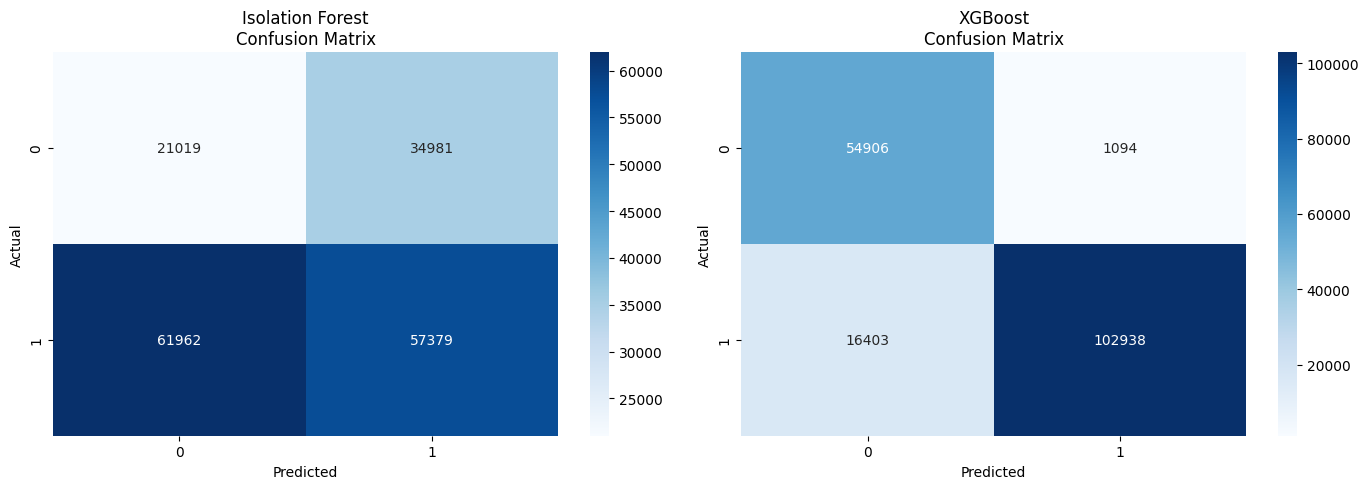

In [6]:
# 혼동행렬 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Isolation Forest
cm_iso = confusion_matrix(y_test, y_pred_iso)
sns.heatmap(cm_iso, annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Isolation Forest\nConfusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', ax=axes[1], cmap='Blues')
axes[1].set_title('XGBoost\nConfusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix.png')
plt.show()

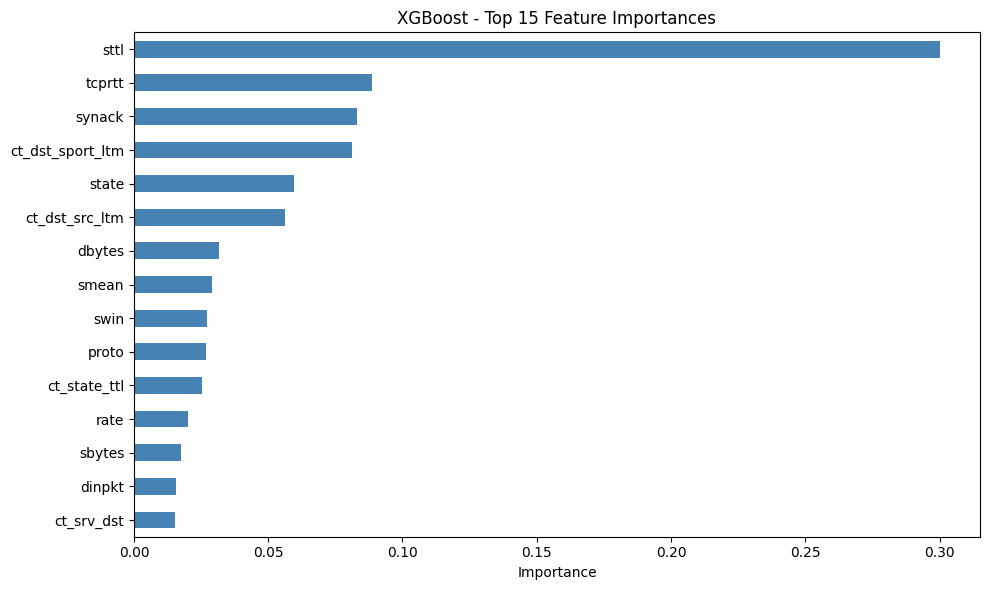

In [7]:
# 피처 중요도 시각화
feature_names = pd.read_csv('../data/raw/UNSW_NB15_training-set.csv').drop(
    columns=['id', 'attack_cat', 'label']).columns.tolist()

importances = pd.Series(xgb.feature_importances_, index=feature_names)
top15 = importances.nlargest(15)

plt.figure(figsize=(10, 6))
top15.sort_values().plot(kind='barh', color='steelblue')
plt.title('XGBoost - Top 15 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../data/processed/feature_importance.png')
plt.show()

In [8]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# XGBoost 모델 저장
joblib.dump(xgb, '../models/xgb_model.joblib')

# Isolation Forest도 저장 (비교용)
joblib.dump(iso_forest, '../models/iso_forest.joblib')

print("모델 저장 완료!")
print("저장 경로: ../models/")

모델 저장 완료!
저장 경로: ../models/
